In [16]:
import sys
sys.path.append("../scripts")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.stats import poisson
from sqlalchemy import text
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from data_collection import engine

In [17]:
# ── Load enriched dataset ──
# New joins: bullpen_stats for opponent relief quality
# New pitcher columns: era_last5, whip_last5, k_per_9_last5, era_vs_rhb, whip_vs_rhb
with engine.connect() as conn:
    df = pd.read_sql(text("""
        SELECT
            w.game_id,
            w.date,
            w.season,
            w.home_away,
            w.tb,
            w.opponent_id,
            p.throws,
            p.era,
            p.whip,
            p.k_per_9,
            p.era_last5,
            p.whip_last5,
            p.k_per_9_last5,
            p.era_vs_rhb,
            p.whip_vs_rhb,
            b.bullpen_era,
            b.bullpen_whip,
            b.bullpen_k_per_9,
            pf.park_factor,
            pf.park_factor_hr
        FROM witt_game_logs w
        JOIN pitcher_game_logs p ON w.game_id = p.game_id
        JOIN bullpen_stats b ON w.game_id = b.game_id
        JOIN park_factors pf ON (
            CASE WHEN w.home_away = 'home' THEN 118
                 ELSE w.opponent_id
            END = pf.team_id
        )
        ORDER BY w.date
    """), conn)

print(df.shape)
print(df.head())

(626, 20)
   game_id        date  season home_away  tb  opponent_id throws  era  whip  \
0   662766  2022-04-07    2022      home   2          114      R  4.2   1.3   
1   662765  2022-04-09    2022      home   0          114      R  4.2   1.3   
2   662755  2022-04-10    2022      home   2          114      R  4.2   1.3   
3   662754  2022-04-11    2022      home   0          114      R  4.2   1.3   
4   662017  2022-04-12    2022      away   0          138      R  4.2   1.3   

   k_per_9  era_last5  whip_last5  k_per_9_last5  era_vs_rhb  whip_vs_rhb  \
0      8.8        4.2         1.3            8.8         4.2          1.3   
1      8.8        4.2         1.3            8.8         4.2          1.3   
2      8.8        4.2         1.3            8.8         4.2          1.3   
3      8.8        4.2         1.3            8.8         4.2          1.3   
4      8.8        4.2         1.3            8.8         4.2          1.3   

   bullpen_era  bullpen_whip  bullpen_k_per_9  park_

In [18]:
# ── Feature engineering ──
df = df.sort_values("date").reset_index(drop=True)

df["tb_avg_7"]  = df["tb"].shift(1).rolling(7,  min_periods=3).mean()
df["tb_avg_15"] = df["tb"].shift(1).rolling(15, min_periods=7).mean()
df["tb_lag1"]   = df["tb"].shift(1)
df["is_home"]   = (df["home_away"] == "home").astype(int)
df["pitcher_r"] = (df["throws"] == "R").astype(int)

df_model = df.dropna(subset=["tb_avg_7", "tb_avg_15", "tb_lag1"]).reset_index(drop=True)

print(df_model.shape)
print(df_model.isnull().sum())  # check for unexpected nulls in new columns

(619, 25)
game_id            0
date               0
season             0
home_away          0
tb                 0
opponent_id        0
throws             0
era                0
whip               0
k_per_9            0
era_last5          0
whip_last5         0
k_per_9_last5      0
era_vs_rhb         0
whip_vs_rhb        0
bullpen_era        0
bullpen_whip       0
bullpen_k_per_9    0
park_factor        0
park_factor_hr     0
tb_avg_7           0
tb_avg_15          0
tb_lag1            0
is_home            0
pitcher_r          0
dtype: int64


In [19]:
# ── Define features and target ──
# V3 additions: era_last5, whip_last5, era_vs_rhb, whip_vs_rhb, bullpen cols
# Dropped: k_per_9_last5 and whip_vs_rhb are likely correlated with era equivalents
FEATURES = [
    # Witt form
    "tb_lag1",
    "tb_avg_7",
    "tb_avg_15",
    # Game context
    "is_home",
    "pitcher_r",
    # Starter season stats
    "era",
    "whip",
    "k_per_9",
    # Starter recent form
    "era_last5",
    "whip_last5",
    # Starter vs RHB (Witt bats right)
    "era_vs_rhb",
    # Bullpen quality
    "bullpen_era",
    "bullpen_whip",
    # Park
    "park_factor",
    "park_factor_hr",
]

TARGET = "tb"

X = df_model[FEATURES]
y = df_model[TARGET]

print(X.shape)
print(y.describe())

(619, 15)
count    619.000000
mean       2.017771
std        1.993032
min        0.000000
25%        0.500000
50%        2.000000
75%        3.000000
max       11.000000
Name: tb, dtype: float64


In [20]:
# ── Scale features ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES)

In [21]:
# ── Baseline ──
naive_pred = np.full(len(y), y.mean())
naive_mae  = mean_absolute_error(y, naive_pred)
print(f"Naive baseline MAE (always predict mean): {naive_mae:.3f}")

Naive baseline MAE (always predict mean): 1.511


In [22]:
# ── Cross-validation ──
model = PoissonRegressor(alpha=1.0, max_iter=300)

tscv = TimeSeriesSplit(n_splits=5)

cv_mae  = -cross_val_score(model, X_scaled, y, cv=tscv, scoring="neg_mean_absolute_error")
cv_rmse = -cross_val_score(model, X_scaled, y, cv=tscv, scoring="neg_root_mean_squared_error")

print(f"CV MAE  per fold: {[round(v,3) for v in cv_mae]}")
print(f"CV RMSE per fold: {[round(v,3) for v in cv_rmse]}")
print(f"\nMAE  mean ± std: {cv_mae.mean():.3f} ± {cv_mae.std():.3f}")
print(f"RMSE mean ± std: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")
print(f"\nBaseline MAE:    {naive_mae:.3f}")
print(f"Improvement:     {naive_mae - cv_mae.mean():.3f}")
print(f"\n── vs V2 Poisson (MAE 1.502) ──")
print(f"Delta from V2:   {1.502 - cv_mae.mean():.3f}")

CV MAE  per fold: [np.float64(1.378), np.float64(1.754), np.float64(1.623), np.float64(1.346), np.float64(1.42)]
CV RMSE per fold: [np.float64(1.802), np.float64(2.343), np.float64(2.272), np.float64(1.785), np.float64(1.77)]

MAE  mean ± std: 1.504 ± 0.158
RMSE mean ± std: 1.995 ± 0.257

Baseline MAE:    1.511
Improvement:     0.007

── vs V2 Poisson (MAE 1.502) ──
Delta from V2:   -0.002


In [23]:
# ── Fit on full dataset ──
model.fit(X_scaled, y)

lambda_preds  = model.predict(X_scaled)
insample_mae  = mean_absolute_error(y, lambda_preds)
insample_rmse = root_mean_squared_error(y, lambda_preds)

print(f"In-sample MAE:  {insample_mae:.3f}")
print(f"In-sample RMSE: {insample_rmse:.3f}")
print(f"CV MAE:         {cv_mae.mean():.3f}")
print(f"\nGap (CV - in-sample): {cv_mae.mean() - insample_mae:.3f}")
print("(large gap = overfitting)")

In-sample MAE:  1.505
In-sample RMSE: 1.961
CV MAE:         1.504

Gap (CV - in-sample): -0.001
(large gap = overfitting)


In [24]:
# ── Over/under probabilities ──
df_model["lambda"]   = lambda_preds
df_model["p_over_0"] = 1 - poisson.cdf(0, lambda_preds)   # P(TB >= 1)
df_model["p_over_1"] = 1 - poisson.cdf(1, lambda_preds)   # P(TB >= 2, over 1.5)
df_model["p_over_2"] = 1 - poisson.cdf(2, lambda_preds)   # P(TB >= 3, over 2.5)

print(df_model[["date", "tb", "lambda", "p_over_0", "p_over_1", "p_over_2"]].head(10))
print(f"\nMean predicted lambda: {lambda_preds.mean():.3f}")
print(f"Mean P(over 1.5 TB):   {df_model['p_over_1'].mean():.3f}")
print(f"Actual rate over 1.5:  {(y >= 2).mean():.3f}")

         date  tb    lambda  p_over_0  p_over_1  p_over_2
0  2022-04-16   2  2.380025  0.907452  0.687185  0.425064
1  2022-04-19   0  2.057780  0.872263  0.609408  0.338959
2  2022-04-20   0  2.300926  0.899834  0.669359  0.404207
3  2022-04-21   2  2.003488  0.865136  0.594937  0.324268
4  2022-04-22   1  1.841508  0.841422  0.549399  0.280518
5  2022-04-23   2  1.625764  0.803239  0.483351  0.223321
6  2022-04-24   1  1.621254  0.802349  0.481907  0.222148
7  2022-04-26   3  1.948991  0.857582  0.580012  0.309520
8  2022-04-27   1  1.645597  0.807103  0.489671  0.228489
9  2022-04-28   1  1.689400  0.815370  0.503455  0.239981

Mean predicted lambda: 2.018
Mean P(over 1.5 TB):   0.595
Actual rate over 1.5:  0.507


Coefficients (log scale):
k_per_9          -0.0639
tb_lag1          -0.0408
tb_avg_7         -0.0255
era_vs_rhb       -0.0184
era_last5        -0.0066
bullpen_whip     -0.0009
whip_last5        0.0005
bullpen_era       0.0012
whip              0.0078
era               0.0242
park_factor_hr    0.0289
park_factor       0.0338
is_home           0.0373
pitcher_r         0.0421
tb_avg_15         0.0493
dtype: float64

Multiplier effect on lambda (exp of coef):
k_per_9           0.938
tb_lag1           0.960
tb_avg_7          0.975
era_vs_rhb        0.982
era_last5         0.993
bullpen_whip      0.999
whip_last5        1.000
bullpen_era       1.001
whip              1.008
era               1.024
park_factor_hr    1.029
park_factor       1.034
is_home           1.038
pitcher_r         1.043
tb_avg_15         1.051
dtype: float64


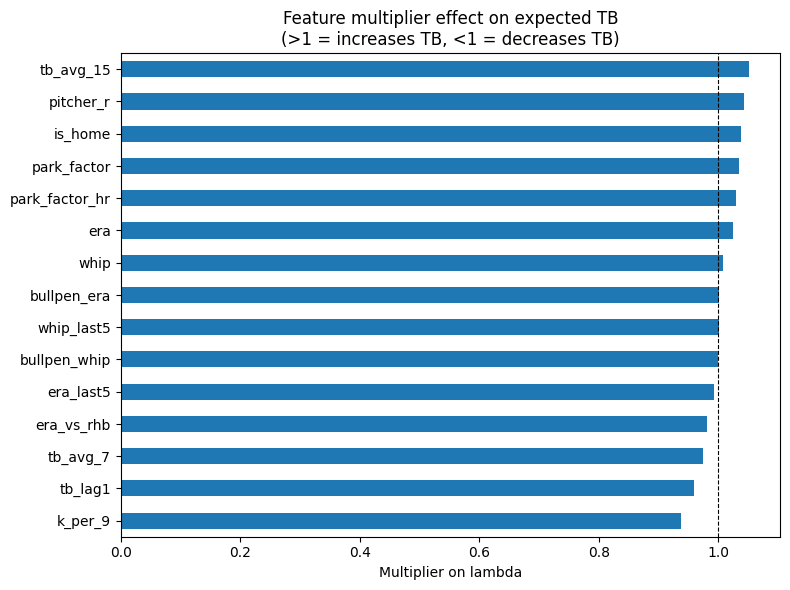

In [25]:
# ── Feature coefficients ──
coefs = pd.Series(model.coef_, index=FEATURES).sort_values()
print("Coefficients (log scale):")
print(coefs.round(4))
print("\nMultiplier effect on lambda (exp of coef):")
print(np.exp(coefs).round(3))

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
np.exp(coefs).sort_values().plot(kind="barh", ax=ax)
ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Feature multiplier effect on expected TB\n(>1 = increases TB, <1 = decreases TB)")
ax.set_xlabel("Multiplier on lambda")
plt.tight_layout()
plt.show()

In [30]:
# ── Calibration check ──
df_model["pred_bin"] = pd.qcut(df_model["p_over_1"], q=5, labels=False)
calibration = df_model.groupby("pred_bin").agg(
    mean_predicted=("p_over_1", "mean"),
    actual_rate=("tb", lambda x: (x >= 2).mean()),
    n=("tb", "count")
).round(3)

print(calibration)
print("\n(well-calibrated = predicted and actual rates close in each bin)")

          mean_predicted  actual_rate    n
pred_bin                                  
0                  0.505        0.379  124
1                  0.562        0.532  124
2                  0.597        0.553  123
3                  0.632        0.460  124
4                  0.680        0.613  124

(well-calibrated = predicted and actual rates close in each bin)


In [27]:
# ── Save model and scaler ──
joblib.dump(model,  "../models/witt_poisson_v3_model.pkl")
joblib.dump(scaler, "../models/witt_poisson_v3_scaler.pkl")
print("Model saved to models/witt_poisson_v3_model.pkl")
print("Scaler saved to models/witt_poisson_v3_scaler.pkl")

Model saved to models/witt_poisson_v3_model.pkl
Scaler saved to models/witt_poisson_v3_scaler.pkl


In [29]:
# ── Calibration: Platt scaling ──
# Take model's p_over_1 predictions and fit a logistic regression
# to map them to better-calibrated probabilities
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

# Binary target: did Witt go over 1.5 TB?
y_binary = (y >= 2).astype(int)

# Raw model probabilities
p_raw = df_model["p_over_1"].values.reshape(-1, 1)

# Fit Platt scaler on same data (in production you'd use a held-out set)
platt = LogisticRegression()
platt.fit(p_raw, y_binary)

# Calibrated probabilities
df_model["p_over_1_cal"] = platt.predict_proba(p_raw)[:, 1]

print(f"Mean raw probability:        {df_model['p_over_1'].mean():.3f}")
print(f"Mean calibrated probability: {df_model['p_over_1_cal'].mean():.3f}")
print(f"Actual rate over 1.5:        {y_binary.mean():.3f}")

Mean raw probability:        0.595
Mean calibrated probability: 0.507
Actual rate over 1.5:        0.507


In [31]:
df_model["pred_bin_cal"] = pd.qcut(df_model["p_over_1_cal"], q=5, labels=False)

cal_adjusted = df_model.groupby("pred_bin_cal").agg(
    mean_predicted=("p_over_1_cal", "mean"),
    actual_rate=("tb", lambda x: (x >= 2).mean()),
    n=("tb", "count")
).round(3)

print("── Raw ──")
print(df_model.groupby("pred_bin").agg(
    mean_predicted=("p_over_1", "mean"),
    actual_rate=("tb", lambda x: (x >= 2).mean()),
    n=("tb", "count")
).round(3))

print("\n── Calibrated ──")
print(cal_adjusted)

── Raw ──
          mean_predicted  actual_rate    n
pred_bin                                  
0                  0.505        0.379  124
1                  0.562        0.532  124
2                  0.597        0.553  123
3                  0.632        0.460  124
4                  0.680        0.613  124

── Calibrated ──
              mean_predicted  actual_rate    n
pred_bin_cal                                  
0                      0.471        0.379  124
1                      0.494        0.532  124
2                      0.508        0.553  123
3                      0.522        0.460  124
4                      0.541        0.613  124
